# Data exploration of collision_dataset.txt
An exploration of the dataset generated by Benjamin Vollebregt using CTC simulations for two colliding $H_2$ molecules.

## Info

### Dataset explanation

$\mathrm{CTC\_simulation\_results\_m}i\mathrm{\_m}j\mathrm{.csv}$ files contain the results of 10.000 independent collisions between two $H_2$ molecules. i and j indicate the multiplicity of the masses of the hydrogen atoms for each molecule. For example, in $\mathrm{CTC\_simulation\_results\_m}1\mathrm{\_m}2\mathrm{.csv}$, the first molecule has two hydrogen atoms with mass 1 (normal hydrogen), and the second molecule has two hydrogen atoms with mass 2 (deuterium). Hydrogen atoms with unrealistic masses (4 or more) can also be simulated this way to study the effect of mass on collision outcomes.

# Velocity inspection

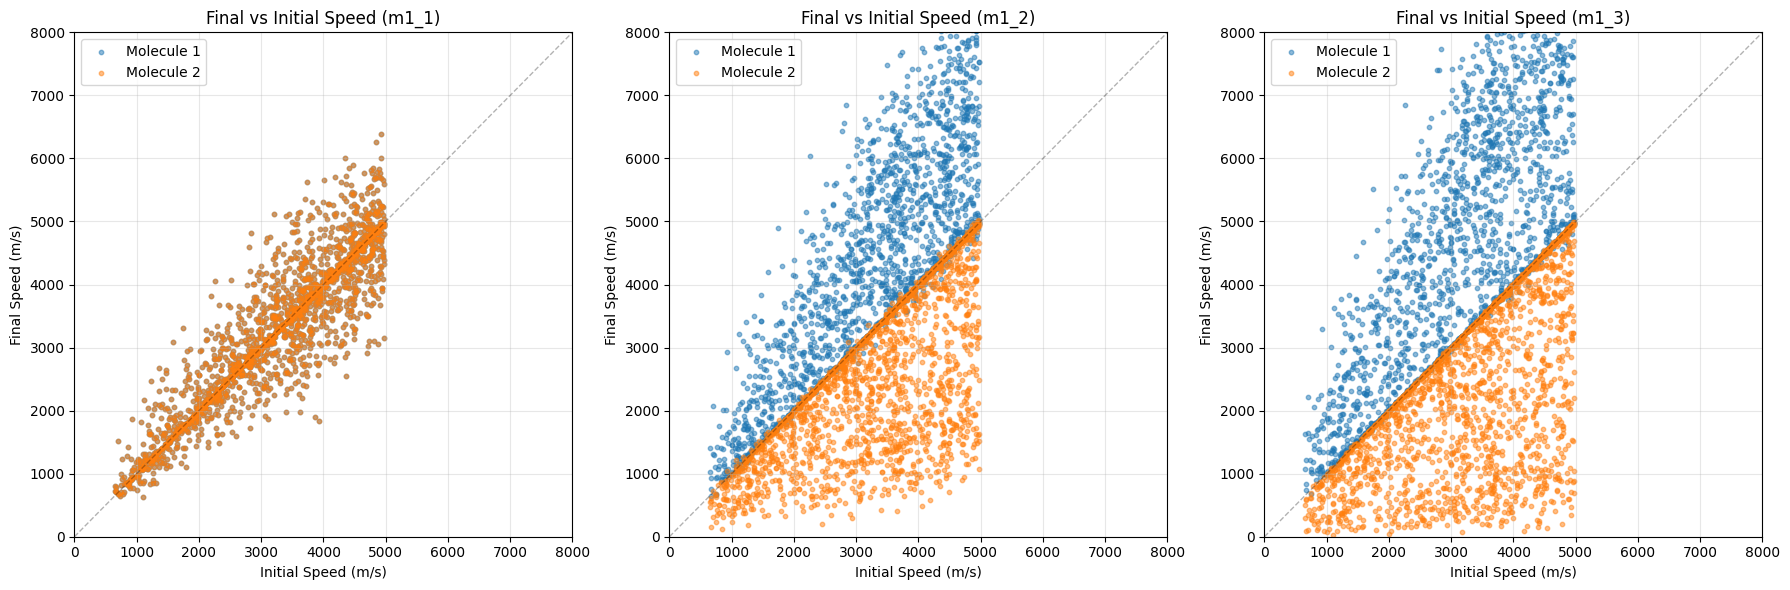

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

m1_1_DATA_FILE = "CTC_simulation_results_m1_m1.csv"
m1_2_DATA_FILE = "CTC_simulation_results_m1_m2.csv"
m1_3_DATA_FILE = "CTC_simulation_results_m1_m3.csv"

df_m1_1 = pd.read_csv(m1_1_DATA_FILE)
df_m1_2 = pd.read_csv(m1_2_DATA_FILE)
df_m1_3 = pd.read_csv(m1_3_DATA_FILE)
datasets = [df_m1_1, df_m1_2, df_m1_3]
dataset_names = ["m1_1", "m1_2", "m1_3"]
nr_datasets = len(datasets)

# Plot initial vs final speed for both molecules in each dataset
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for i, (df, name) in enumerate(zip(datasets, dataset_names)):
    # Molecule 1
    ax[i].scatter(df["V1_init"], df["V1_final"], alpha=0.5, label='Molecule 1', s=10)
    # Molecule 2
    ax[i].scatter(df["V2_init"], df["V2_final"], alpha=0.5, label='Molecule 2', s=10)
    
    ax[i].set_xlim(0, 8000)
    ax[i].set_ylim(0, 8000)
    ax[i].set_xlabel("Initial Speed (m/s)")
    ax[i].set_ylabel("Final Speed (m/s)")
    ax[i].set_title(f"Final vs Initial Speed ({name})")
    ax[i].legend()
    ax[i].grid(alpha=0.3)
    ax[i].plot([0, 8000], [0, 8000], 'k--', alpha=0.3, linewidth=1)  # diagonal reference line

plt.tight_layout()
plt.show()

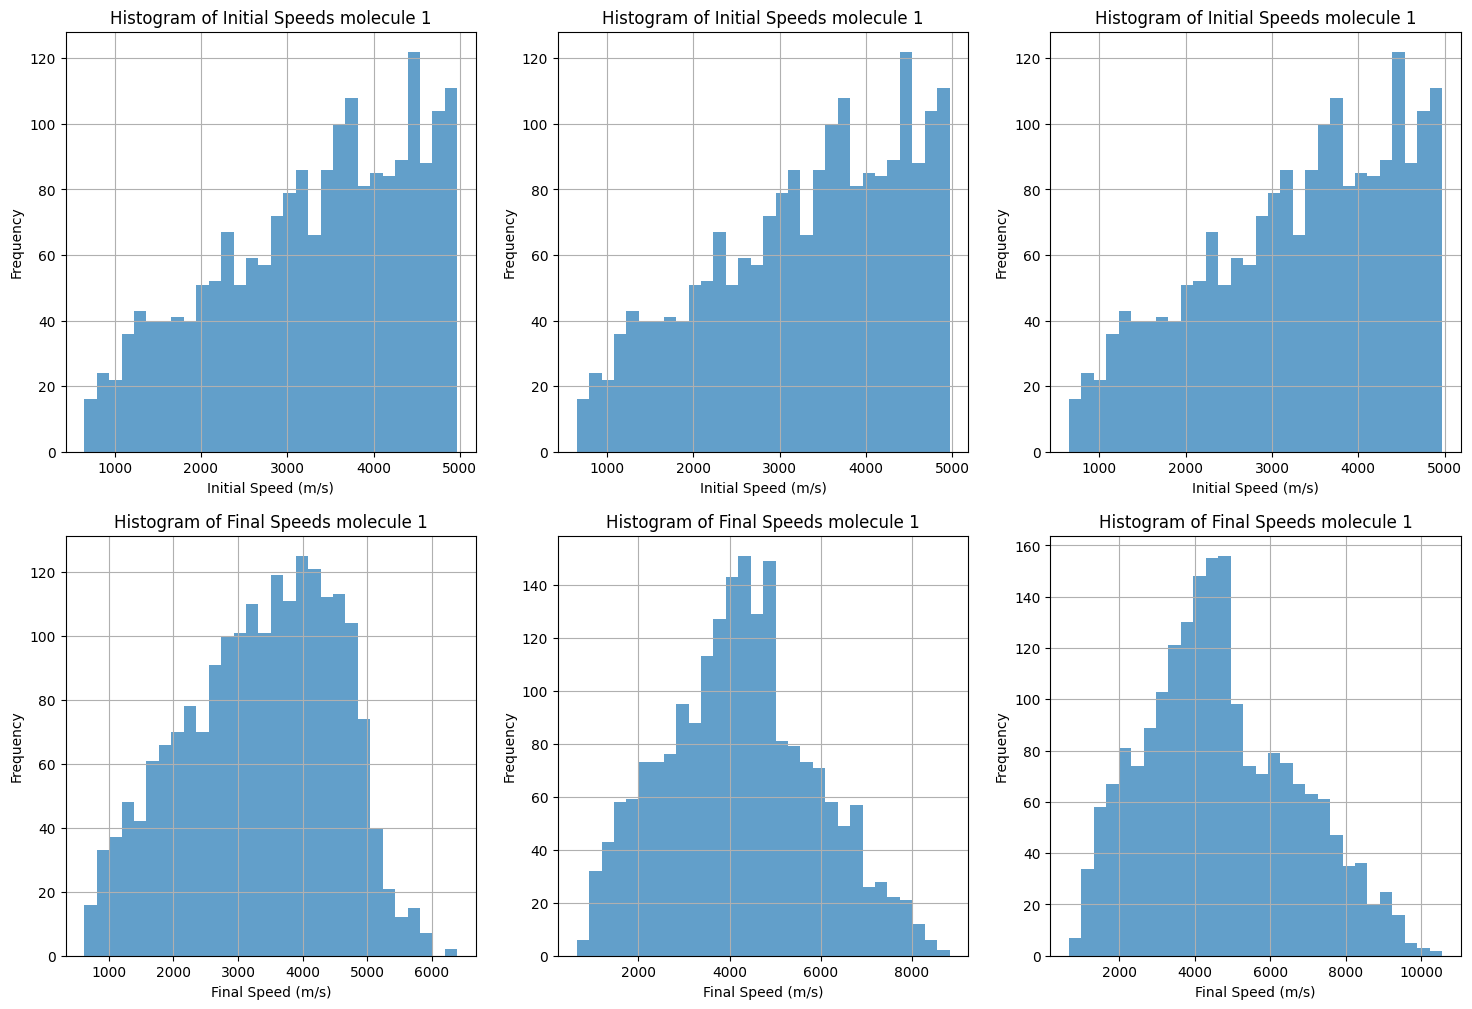

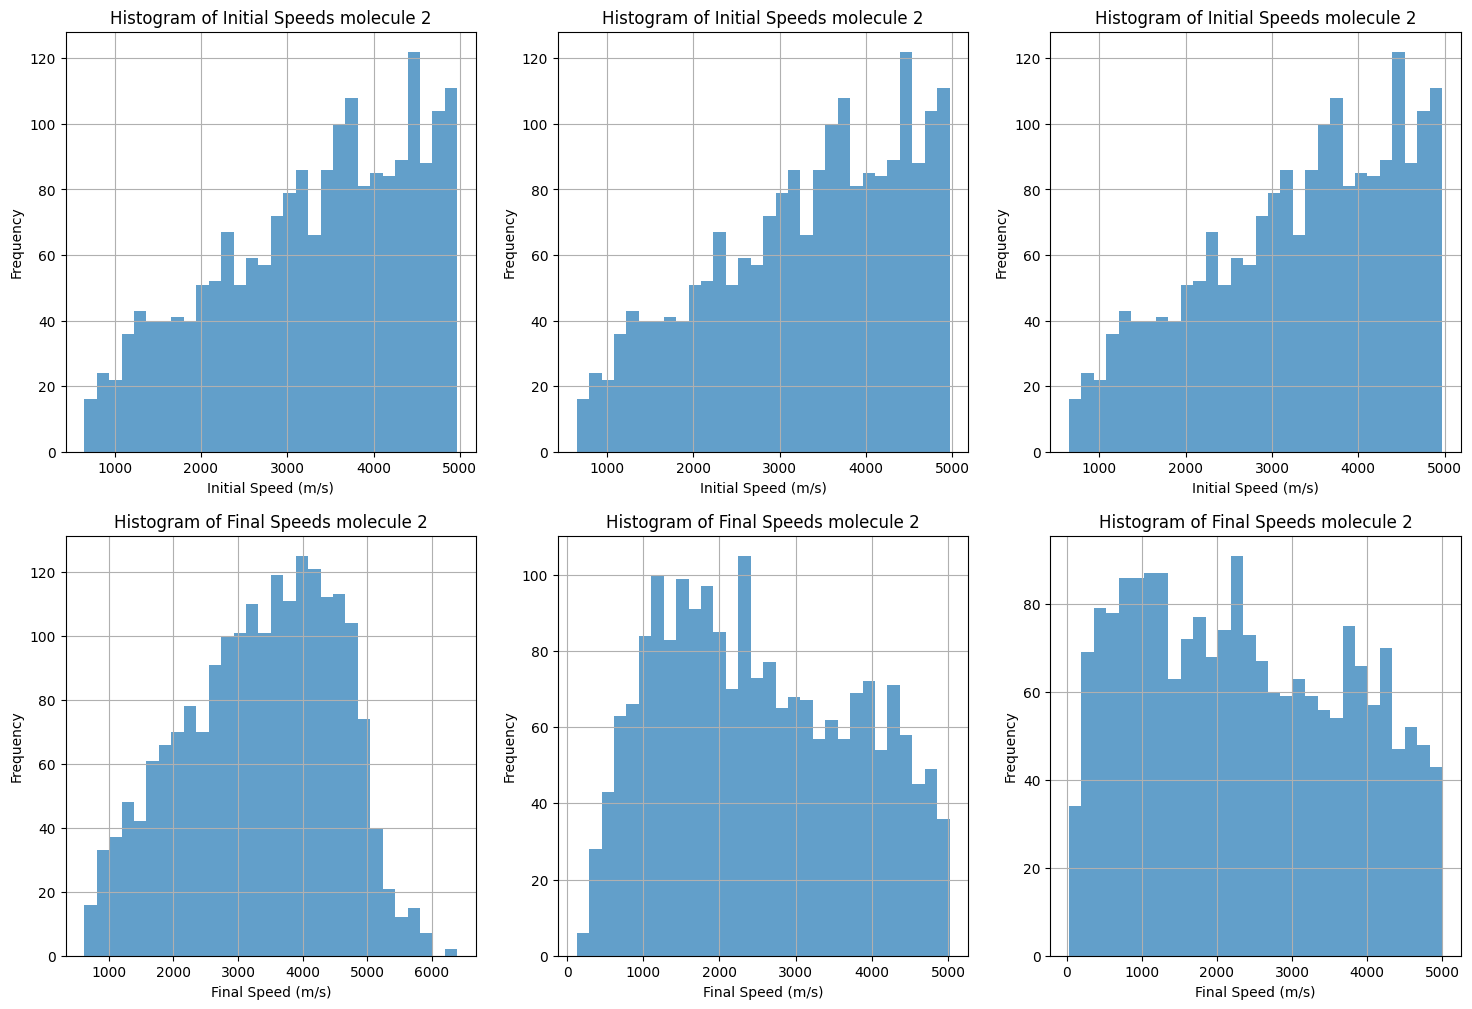

In [ ]:
# Histograms of initial and final speeds for all data
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

for i, (df, name) in enumerate(zip(datasets, dataset_names)):
    # Molecule 1
    ax[0, i].hist(df["V1_init"], bins=30, alpha=0.6, label='Pre-collision', color='blue')
    ax[0, i].hist(df["V1_final"], bins=30, alpha=0.6, label='Post-collision', color='orange')
    ax[0, i].set_xlabel("Speed (m/s)")
    ax[0, i].set_ylabel("Frequency")
    ax[0, i].set_title(f"Molecule 1 Speed Distribution ({name})")
    ax[0, i].legend()
    ax[0, i].grid(alpha=0.3)
    
    # Molecule 2
    ax[1, i].hist(df["V2_init"], bins=30, alpha=0.6, label='Pre-collision', color='blue')
    ax[1, i].hist(df["V2_final"], bins=30, alpha=0.6, label='Post-collision', color='orange')
    ax[1, i].set_xlabel("Speed (m/s)")
    ax[1, i].set_ylabel("Frequency")
    ax[1, i].set_title(f"Molecule 2 Speed Distribution ({name})")
    ax[1, i].legend()
    ax[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

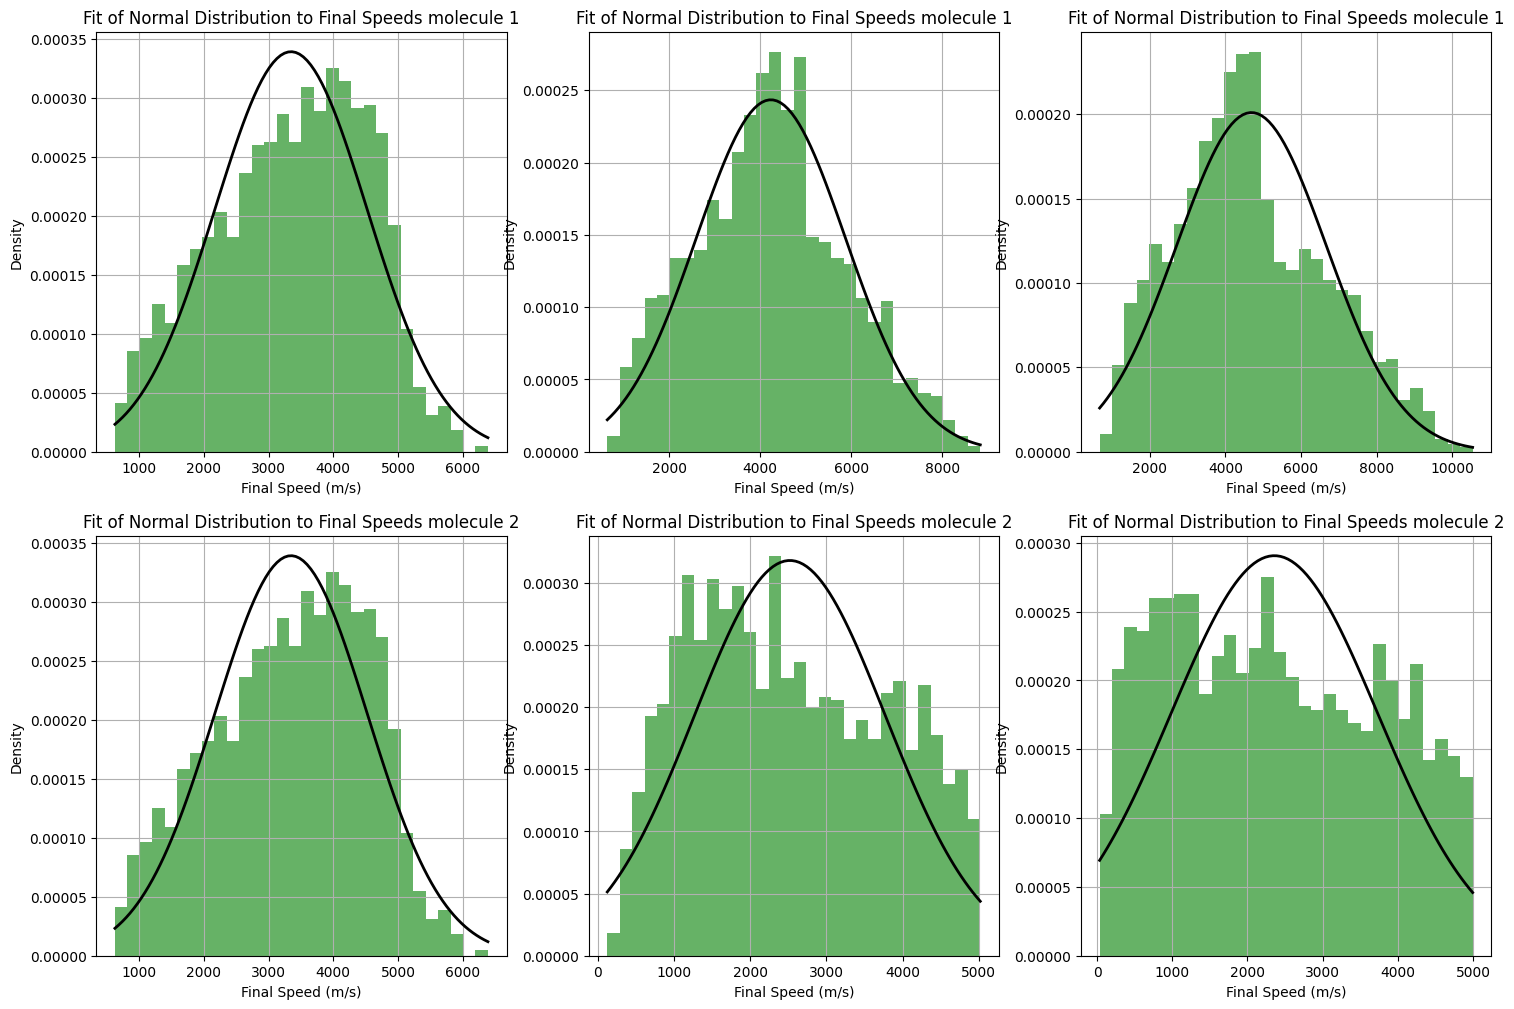

In [41]:
# Fit pdf to final speed data
fig, ax = plt.subplots(2, nr_datasets, figsize=(18, 4*nr_datasets))
for i,dataset in enumerate(datasets):
    final_speeds_1 = dataset[f"V1_final"].dropna()
    final_speeds_2 = dataset[f"V2_final"].dropna()
    mu_1, std_1 = stats.norm.fit(final_speeds_1)
    mu_2, std_2 = stats.norm.fit(final_speeds_2)
    xmin_1, xmax_1 = final_speeds_1.min(), final_speeds_1.max()
    xmin_2, xmax_2 = final_speeds_2.min(), final_speeds_2.max()
    x_1 = np.linspace(xmin_1, xmax_1, 100)
    x_2 = np.linspace(xmin_2, xmax_2, 100)
    p_1 = stats.norm.pdf(x_1, mu_1, std_1)
    p_2 = stats.norm.pdf(x_2, mu_2, std_2)
    ax[0,i].hist(final_speeds_1, bins=30, density=True, alpha=0.6, color='g')
    ax[0,i].plot(x_1, p_1, 'k', linewidth=2)
    ax[0,i].set_xlabel("Final Speed (m/s)")
    ax[0,i].set_ylabel("Density")
    ax[0,i].set_title(f"Fit of Normal Distribution to Final Speeds molecule 1")
    ax[0,i].grid()
    ax[1,i].hist(final_speeds_2, bins=30, density=True, alpha=0.6, color='g')
    ax[1,i].plot(x_2, p_2, 'k', linewidth=2)
    ax[1,i].set_xlabel("Final Speed (m/s)")
    ax[1,i].set_ylabel("Density")
    ax[1,i].set_title(f"Fit of Normal Distribution to Final Speeds molecule 2")
    ax[1,i].grid()
plt.show()

# Energy inspection

Dataset 1 - Molecule 1 KL Divergence D_KL(V_final || V_init): 1.3467
Dataset 1 - Molecule 2 KL Divergence D_KL(V_final || V_init): 1.3467
Dataset 2 - Molecule 1 KL Divergence D_KL(V_final || V_init): 7.6173
Dataset 2 - Molecule 2 KL Divergence D_KL(V_final || V_init): 1.1712
Dataset 3 - Molecule 1 KL Divergence D_KL(V_final || V_init): 9.3580
Dataset 3 - Molecule 2 KL Divergence D_KL(V_final || V_init): 3.2679
Dataset 3 - Molecule 2 KL Divergence D_KL(V_final || V_init): 3.2679


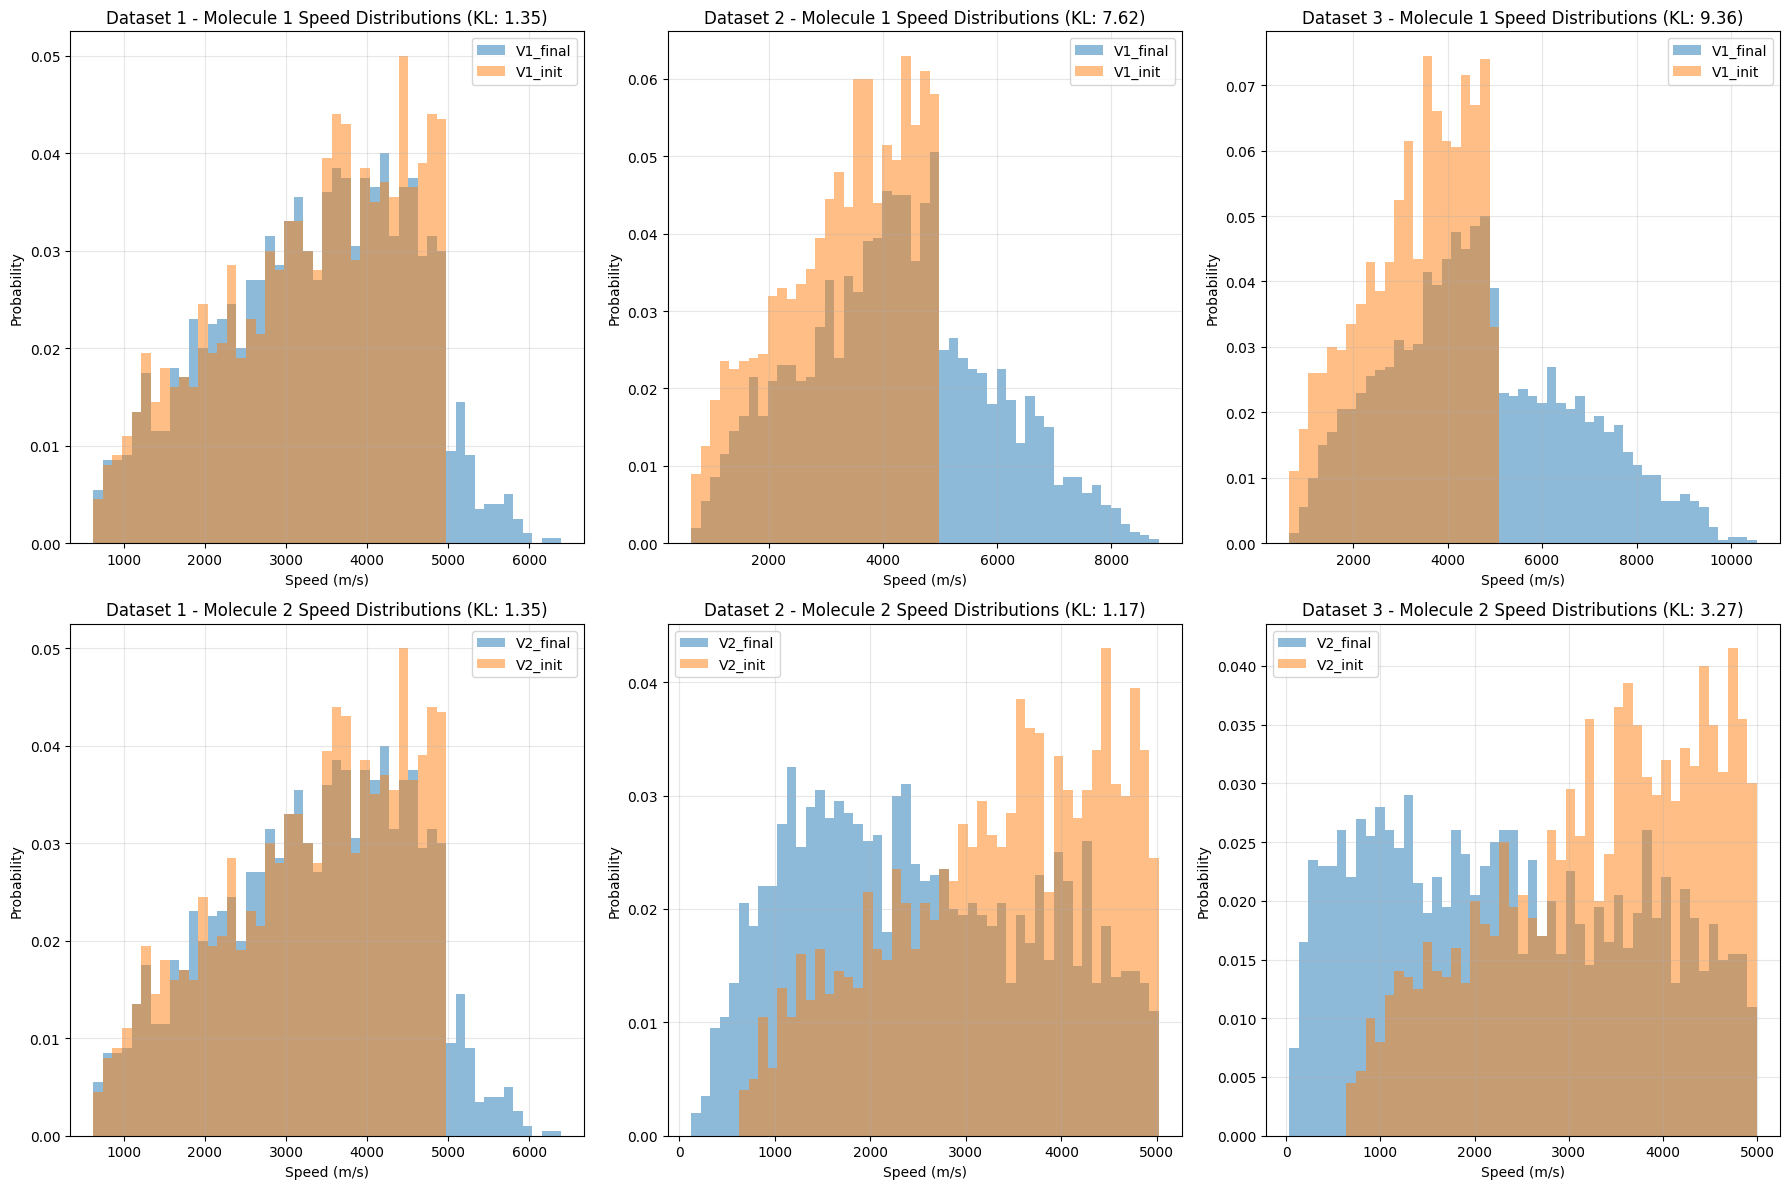

In [42]:
from scipy.stats import entropy

num_bins = 50
fig, ax = plt.subplots(2, nr_datasets, figsize=(18, 4*nr_datasets))
for i in range(nr_datasets):
    # Molecule 1
    v1_init = datasets[i]["V1_init"].dropna().values
    v1_final = datasets[i]["V1_final"].dropna().values

    min_val_1 = min(v1_init.min(), v1_final.min())
    max_val_1 = max(v1_init.max(), v1_final.max())
    bins_1 = np.linspace(min_val_1, max_val_1, num_bins)

    v1_final_counts, _ = np.histogram(v1_final, bins=bins_1)
    v1_init_counts, _ = np.histogram(v1_init, bins=bins_1)

    epsilon = 1e-10
    v1_final_counts = v1_final_counts + epsilon
    v1_init_counts = v1_init_counts + epsilon

    v1_final_norm = v1_final_counts / np.sum(v1_final_counts)
    v1_init_norm = v1_init_counts / np.sum(v1_init_counts)

    kl_divergence_1 = entropy(v1_final_norm, v1_init_norm)
    print(f"Dataset {i+1} - Molecule 1 KL Divergence D_KL(V_final || V_init): {kl_divergence_1:.4f}")

    # Plot molecule 1
    ax[0, i].bar(bins_1[:-1], v1_final_norm, width=np.diff(bins_1), alpha=0.5, label='V1_final', align='edge')
    ax[0, i].bar(bins_1[:-1], v1_init_norm, width=np.diff(bins_1), alpha=0.5, label='V1_init', align='edge')
    ax[0, i].set_title(f"Dataset {i+1} - Molecule 1 Speed Distributions (KL: {kl_divergence_1:.2f})")
    ax[0, i].set_xlabel("Speed (m/s)")
    ax[0, i].set_ylabel("Probability")
    ax[0, i].legend()
    ax[0, i].grid(alpha=0.3)

    # Molecule 2
    v2_init = datasets[i]["V2_init"].dropna().values
    v2_final = datasets[i]["V2_final"].dropna().values

    min_val_2 = min(v2_init.min(), v2_final.min())
    max_val_2 = max(v2_init.max(), v2_final.max())
    bins_2 = np.linspace(min_val_2, max_val_2, num_bins)

    v2_final_counts, _ = np.histogram(v2_final, bins=bins_2)
    v2_init_counts, _ = np.histogram(v2_init, bins=bins_2)

    v2_final_counts = v2_final_counts + epsilon
    v2_init_counts = v2_init_counts + epsilon

    v2_final_norm = v2_final_counts / np.sum(v2_final_counts)
    v2_init_norm = v2_init_counts / np.sum(v2_init_counts)

    kl_divergence_2 = entropy(v2_final_norm, v2_init_norm)
    print(f"Dataset {i+1} - Molecule 2 KL Divergence D_KL(V_final || V_init): {kl_divergence_2:.4f}")

    # Plot molecule 2
    ax[1, i].bar(bins_2[:-1], v2_final_norm, width=np.diff(bins_2), alpha=0.5, label='V2_final', align='edge')
    ax[1, i].bar(bins_2[:-1], v2_init_norm, width=np.diff(bins_2), alpha=0.5, label='V2_init', align='edge')
    ax[1, i].set_title(f"Dataset {i+1} - Molecule 2 Speed Distributions (KL: {kl_divergence_2:.2f})")
    ax[1, i].set_xlabel("Speed (m/s)")
    ax[1, i].set_ylabel("Probability")
    ax[1, i].legend()
    ax[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()